In [1]:
# Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

import scipy.cluster.hierarchy as sch

In [ ]:
# Datasets

df_SSMCF7_meta = pd.read_csv("../data/SmartSeq/MCF7/MCF7_SmartS_MetaData.tsv",delimiter=r"\t",engine='python',index_col=0)
df_meta_SSHCC1806 = pd.read_csv("../data/SmartSeq/HCC1806/HCC1806_SmartS_MetaData.tsv",delimiter=r"\t",engine='python',index_col=0)

df_SSMCF7 = pd.read_csv("../data/SmartSeq/MCF7/MCF7_SmartS_Unfiltered_Data.txt",delimiter=r"\ ",engine='python',index_col=0)
df_SSHCC1806 = pd.read_csv("../data/SmartSeq/HCC1806/HCC1806_SmartS_Unfiltered_Data.txt",delimiter=r"\ ",engine='python',index_col=0)
df_DSMCF7 = pd.read_csv("../data/DropSeq/MCF7/MCF7_Filtered_Normalised_3000_Data_train.txt", sep=r"\s+", engine="python", index_col=0)
df_DSHCC1806 = pd.read_csv("../data/DropSeq/HCC1806/HCC1806_Filtered_Normalised_3000_Data_train.txt", sep=r"\s+", engine="python", index_col=0)

df_SSMCF7_Train = pd.read_csv("../data/SmartSeq/MCF7/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",delimiter=r"\ ",engine='python',index_col=0)
df_SSHCC1806_Train = pd.read_csv("../data/SmartSeq/HCC1806/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",delimiter=r"\ ",engine='python',index_col=0)



# Unsupervised Learning

In this next part of the analysis we move to using the already filtered, normalized and split data. Before we start with any type of learning we do some preparations of the databses such that we have a testing and a training set. These sets will be used throughout the learning. 

In [3]:
#Creating a train and test set for the Smartseq MCF7 dataset (Transposed)
df_SSMCF7_Train_T = df_SSMCF7_Train.T
df_SSMCF7_Train_T.index = df_SSMCF7_Train_T.index.str.strip('"')
X_train_SSMCF7, X_test_SSMCF7 = train_test_split(df_SSMCF7_Train_T, test_size=0.2, random_state =0)

#Creating a train and test set for the Smartseq HCC1806 dataset (Transposed)
df_SSHCC1806_Train_T = df_SSHCC1806_Train.T
df_SSHCC1806_Train_T.index = df_SSHCC1806_Train_T.index.str.strip('"')
X_train_SSHCC1806, X_test_SSHCC1806 = train_test_split(df_SSHCC1806_Train_T, test_size=0.2, random_state =10)

df_SSMCF7_Train_T_labels = df_SSMCF7_meta.loc[df_SSMCF7_Train_T.index, 'Condition']

Xtrain_labels_SSMCF7 = df_SSMCF7_meta.loc[X_train_SSMCF7.index, 'Condition']
Xtest_labels_SSMCF7 = df_SSMCF7_meta.loc[X_test_SSMCF7.index, 'Condition']

Xtrain_labels_SSHCC1806 = df_meta_SSHCC1806.loc[X_train_SSHCC1806.index, 'Condition']
Xtest_labels_SSHCC1806 = df_meta_SSHCC1806.loc[X_test_SSHCC1806.index, 'Condition']


In [ ]:
# Export Smartseq train/test splits and labels
Xtrain_labels_SSMCF7.to_csv("../data/processed/Xtrain_labels_SSMCF7.csv", index=True)
Xtest_labels_SSMCF7.to_csv("../data/processed/Xtest_labels_SSMCF7.csv", index=True)

Xtrain_labels_SSHCC1806.to_csv("../data/processed/Xtrain_labels_SSHCC1806.csv", index=True)
Xtest_labels_SSHCC1806.to_csv("../data/processed/Xtest_labels_SSHCC1806.csv", index=True)


In the unsupervised learning section of our code we will start by implementing a PCA on our datasets and then an unsupervised clustering algorithm. This is a good way to kick off the learning as both of these methods look at the underlying structure of the data without us pushing it to look towards a specific aspect such as the hypoxic or normoxic label. This has the potential to reveal how biologicaly different the two classes are and whether the biggest variance in our dataset is due to that difference precisely. 

## DropSeq

### MCF7

#### PCA

Starting with the PCA on DropSeq MCF7 we transpose the predetermined training set, as most models expect samples as columns, and then split it into index values and the data values. The index values contain our labels so this is why we want to separate them. After that we perform a split again leaving 80% of the data to train on and 20 % of the data to test on. 

In [5]:
transpose = df_DSMCF7.T
y = transpose.index.values
X = transpose.values

In [6]:
X_train_MCF7, X_test_MCF7, y_train_MCF7, y_test_MCF7 = train_test_split(X, y, test_size = 0.2, random_state = 0)

todata= pd.DataFrame(X_train_MCF7)
todata.to_csv("../data/processed/X_train_MCF7.csv", index=True)

todata= pd.DataFrame(y_train_MCF7)
todata.to_csv("../data/processed/y_train_MCF7.csv", index=True)

In [7]:
pca = PCA(n_components = 50)
X_train_MCF7 = pca.fit_transform(X_train_MCF7)
X_test_MCF7 = pca.transform(X_test_MCF7)

When we look at the explained varainance form our 50 PCs we see a cumulative score of 65% which is not perfect by any means but it is good enough to be proceed further.

In [8]:
explained_var = pca.explained_variance_ratio_
explained_50 = explained_var.sum()
print("Explained variance by each PC:", explained_var)
print("Explained variance:", explained_50)

Explained variance by each PC: [0.25103489 0.08649174 0.04457727 0.02589892 0.0216182  0.01406446
 0.0129681  0.00998694 0.00932656 0.0084778  0.0082101  0.00730424
 0.00706809 0.00667087 0.00626486 0.00587517 0.00583242 0.0055283
 0.00521872 0.00494186 0.00463545 0.0045021  0.00443904 0.00441009
 0.00430467 0.00424302 0.00405518 0.00402791 0.00396863 0.00385155
 0.00380308 0.00379399 0.00369222 0.00363296 0.00354805 0.00350194
 0.00336088 0.00324641 0.00322784 0.00314658 0.00314411 0.00307258
 0.00286385 0.00285186 0.00277918 0.00271717 0.00268885 0.00265466
 0.00262123 0.00254854]
Explained variance: 0.6526931741531967


Here we simply extract the label from the index values and then turn the labels from strings to 0, 1 integers. 

In [9]:
y_clean_MCF7 = [element.strip('""').split("_")[1] for element in y_train_MCF7]
color_MCF7 = [0 if element == "Normoxia" else 1 for element in y_clean_MCF7]

Plotting the data on our first two PCs we see that there is somewhat of a split of our data along our first pc, but the case is not so simple to be able to say that all of the variance in the first pc is because of the labels. Since we cannot plot the data in 50 dimensions, the best way to check whether there is a clearer split across all PCs is clustering. 

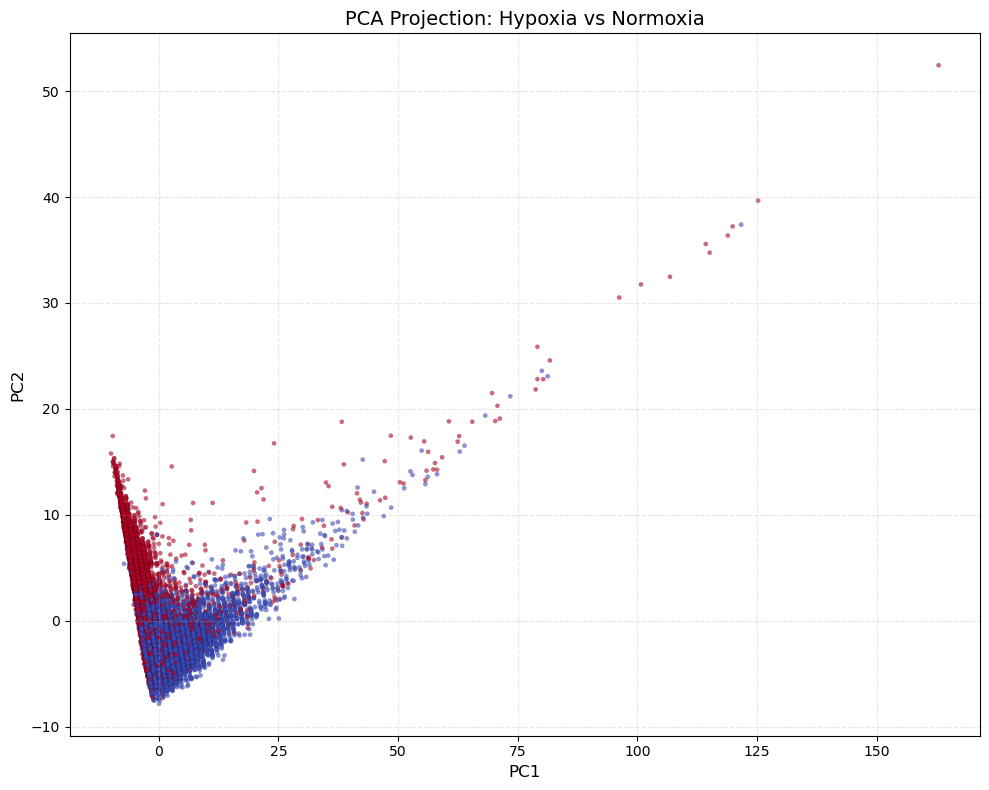

In [10]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_train_MCF7[:, 0], X_train_MCF7[:, 1],
    c=color_MCF7, cmap='coolwarm',
    alpha=0.6, edgecolors='k', linewidths=0.1, s=10
)

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("PCA Projection: Hypoxia vs Normoxia", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Clustering

In this case we proceed with Hierarchical clustering. For clarity of the code we perform the split again but this time, instead of getting our top 50 principal components, we get enough so that the total explained variance is 80%. This is a good threshold to choose as there is still some dimensionality reduction, but we don't lose as much information and we leave 20% to be discarded which is not too bad as it can either be noise or, even if it is meaningful infromation, it is not enough to throw off our models. 

In [11]:
transpose = df_DSMCF7.T
X = transpose.values

In [12]:
X_train_MCF7_clustering, X_test_MCF7_clustering, y_train_MCF7_clustering, y_test_MCF7_clustering = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [13]:
pca = PCA(n_components = 0.8)
X_train_MCF7_clustering = pca.fit_transform(X_train_MCF7_clustering)
X_test_MCF7_clustering = pca.transform(X_test_MCF7_clustering)

In [14]:
explained_var = pca.explained_variance_ratio_
explained_30 = explained_var.sum()
print("Explained variance:", explained_30)

Explained variance: 0.8000265003236541


Plotting the dendrogram, we see that the data has been divided into three clusters which is not as great of a result as we expected. This suggests that the biological differences are not as clear as we would have hoped for, but that does not mean that we won't be able to get better results down the line. 

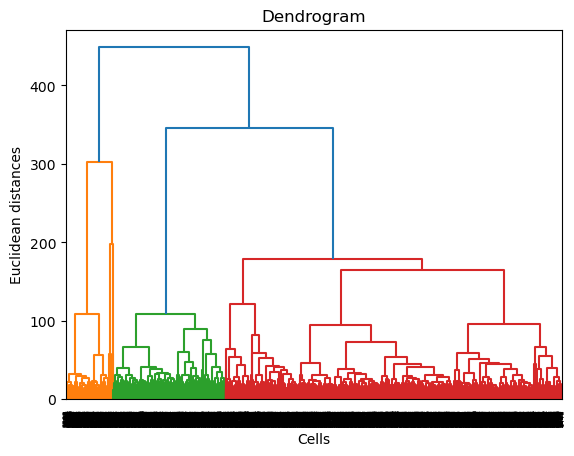

In [15]:
dendrogram = sch.dendrogram(sch.linkage(X_test_MCF7_clustering, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Cells')
plt.ylabel('Euclidean distances')
plt.show()

Below we will be performing the Agglomerative Clustering, coloring the data of the test set on our first two principal components based on the clusters and comparing to the graph below which is coloered according to the true labels. Interestingly, we observe that the general shape of the clustering is similar to the true values, but we can also see many dissimilarities and misclassified points. 

In [16]:
hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_hc_MCF7_clustering = hc.fit_predict(X_test_MCF7_clustering)

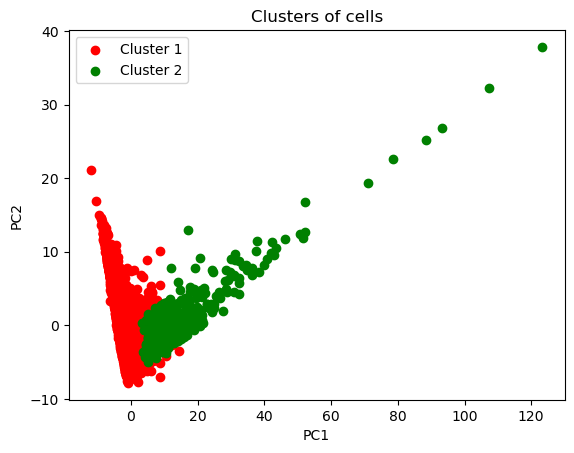

In [17]:
plt.scatter(X_test_MCF7_clustering[y_hc_MCF7_clustering == 0, 0], X_test_MCF7_clustering[y_hc_MCF7_clustering == 0, 1], c = 'red', label = 'Cluster 1')
plt.scatter(X_test_MCF7_clustering[y_hc_MCF7_clustering == 1, 0], X_test_MCF7_clustering[y_hc_MCF7_clustering == 1, 1], c = 'green', label = 'Cluster 2')
plt.title('Clusters of cells')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

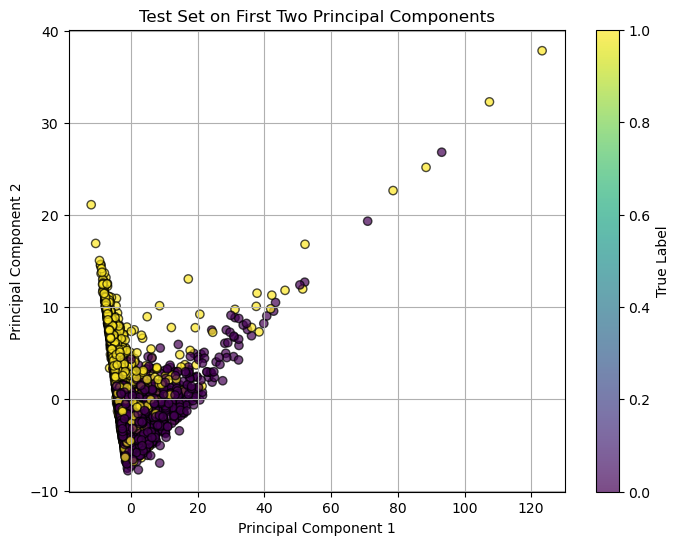

In [18]:
y_clean_MCF7 = [element.strip('""').split("_")[1] for element in y_test_MCF7_clustering]
color_MCF7 = [0 if element == "Normoxia" else 1 for element in y_clean_MCF7]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_test_MCF7_clustering[:, 0], X_test_MCF7_clustering[:, 1],
    c=color_MCF7, cmap='viridis', edgecolor='k', alpha=0.7
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Test Set on First Two Principal Components')
plt.colorbar(scatter, label='True Label')
plt.grid(True)
plt.show()

Concluding the unsupervised learning of the DropSeq MCF7 dataset, we see that the data has some intrinsic biological differences between the two labels, but the difference is not clear enough to be able to rely just on it to train unsupervised models. There are also other differences that come into play which affect our results and hinder the performance of our models. For instance the hierarchical clustering discovered a third cluster even though in the data we have only two separating classes.  

### HCC1806

Next, we continue with the unsupervised learning for the DropSeq HCC1806 dataset. Again, we do tranpsosing, splitting, but this time we also log transform the data. Such a transformation is often useful for methods like pca and clustering which are distance based methods, since too large of a scale for the features could introduce bias towards higher expression levels and cause poorer performance of our models. 

#### PCA

In [19]:
transpose = df_DSHCC1806.T
y = transpose.index.values
X = transpose.values
X = np.log1p(X)

In [20]:
X_train_HCC1806, X_test_HCC1806, y_train_HCC1806, y_test_HCC1806 = train_test_split(X, y, test_size = 0.2, random_state = 0)

todata= pd.DataFrame(X_train_HCC1806)
todata.to_csv("../data/processed/X_train_HCC1806.csv", index=True)

todata= pd.DataFrame(y_train_HCC1806)
todata.to_csv("../data/processed/y_train_HCC1806.csv", index=True)

In [21]:
pca = PCA(n_components = 50)
X_train_HCC1806 = pca.fit_transform(X_train_HCC1806)
X_test_HCC1806 = pca.transform(X_test_HCC1806)

Looking at the explained variance we see that in the first 50 components it is cumulatively less than on the MCF7 case as we reach just 36%. Of course that result is not necessarily bad, but it could suggest that the our main factor of difference in our cells (i.e the label) does not result in as prominent of a biological and genetic difference as initially expected. A low amount of explained variance however is not always necessarily a bad thing as it could potentally be related to precisely our classes while not including any of the noise and other biological differences. 

In [22]:
explained_var = pca.explained_variance_ratio_
explained_30 = explained_var.sum()
print("Explained variance:", explained_30)

Explained variance: 0.36659255874775526


In [23]:
y_clean_HCC1806 = [element.strip('""').split("_")[1] for element in y_train_HCC1806]
color_HCC1806 = [0 if element == "Normoxia" else 1 for element in y_clean_HCC1806]

Plotting that data on our first three principal components we see that the separation does not look too bad. There is mixing of the classes but there are also two relatively distinct clusters which could suggest a good performance with our clustering model. 

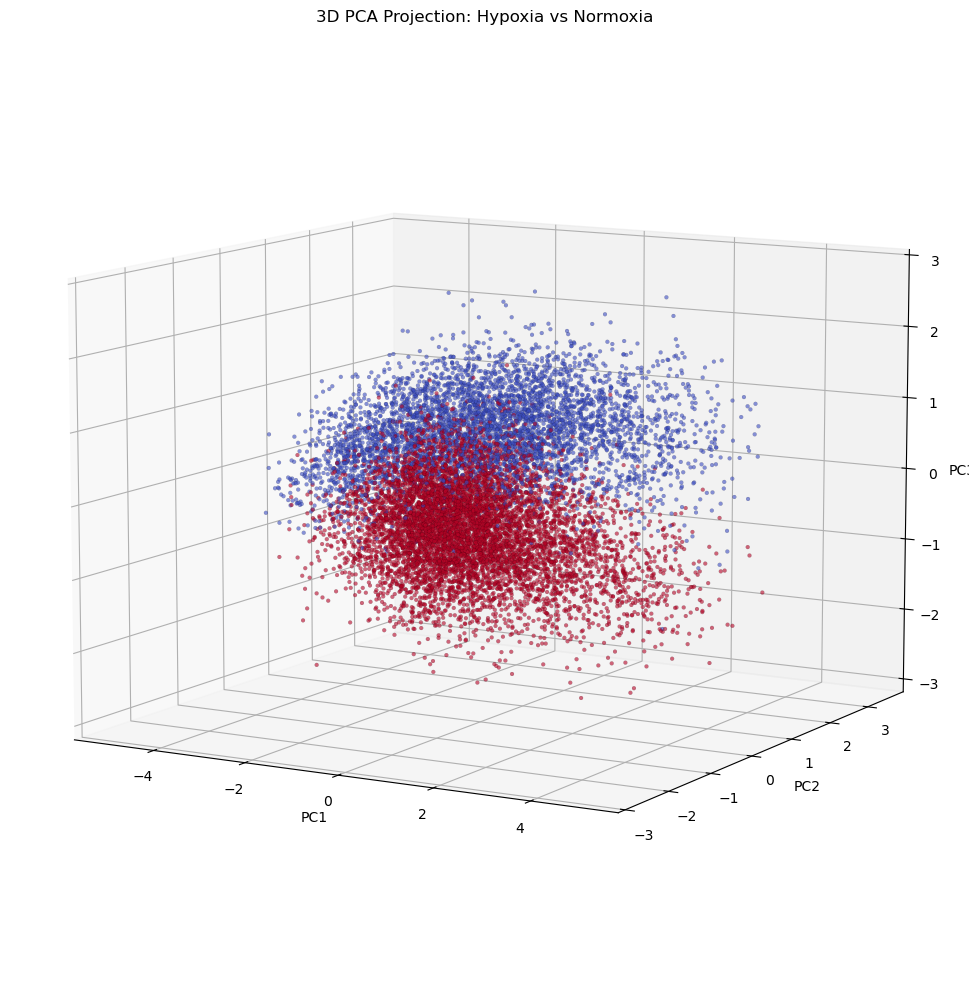

In [24]:
fig = plt.figure(figsize=(13, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.view_init(elev=10)
ax.scatter(
    X_train_HCC1806[:, 0], X_train_HCC1806[:, 1], X_train_HCC1806[:, 2],
    c=color_HCC1806, cmap='coolwarm', alpha=0.6, s=8, edgecolors='k', linewidth=0.1
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection: Hypoxia vs Normoxia')

plt.tight_layout()
plt.show()

#### Clustering

Again we proceed as in the DropSeq MCF7 case, by increasing principal components up to the point where we reach 80% explained variance. 

In [25]:
transpose = df_DSHCC1806.T
X = transpose.values

In [26]:
X_train_HCC1806_clustering, X_test_HCC1806_clustering, y_train_HCC1806_clustering, y_test_HCC1806_clustering = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [27]:
pca = PCA(n_components = 0.8)
X_train_HCC1806_clustering = pca.fit_transform(X_train_HCC1806_clustering)
X_test_HCC1806_clustering = pca.transform(X_test_HCC1806_clustering)

In [28]:
explained_var = pca.explained_variance_ratio_
explained_30 = explained_var.sum()
print("Explained variance:", explained_30)

Explained variance: 0.8001795347458286


Ploting the dendrogram, we see that the data has been divided into three cluster which is not as great of a result as we expected. This sugest that the biological differences are not as clear as we would have hoped for but that does not mean that we want be able to get better results down the line. 

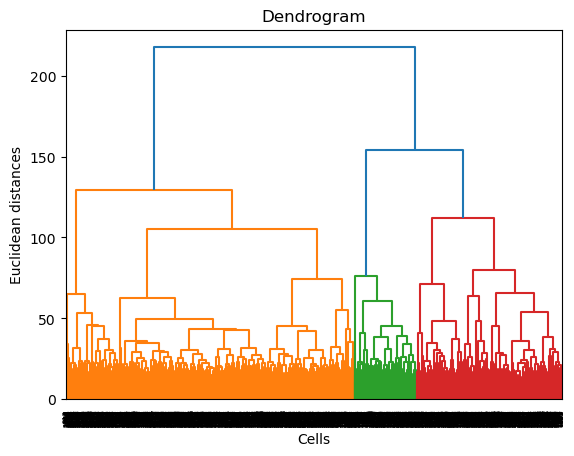

In [29]:

dendrogram = sch.dendrogram(sch.linkage(X_test_HCC1806_clustering, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Cells')
plt.ylabel('Euclidean distances')
plt.show()

In [30]:

hc = AgglomerativeClustering(n_clusters = 2, metric = 'euclidean', linkage = 'ward')
y_hc_HCC1806_clustering = hc.fit_predict(X_test_HCC1806_clustering)

When comparing the results of the clusterin to the true labels, we see that the prediction does not look too good again confirming our belief that the true bilogical differences are more hidden away than in the MCF7 case and a stronger supervised model would be required for better result. 

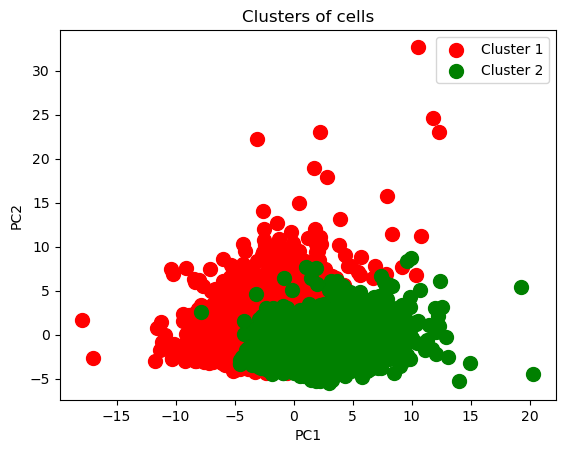

In [31]:
plt.scatter(X_test_HCC1806_clustering[y_hc_HCC1806_clustering == 0, 0], X_test_HCC1806_clustering[y_hc_HCC1806_clustering == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X_test_HCC1806_clustering[y_hc_HCC1806_clustering == 1, 0], X_test_HCC1806_clustering[y_hc_HCC1806_clustering == 1, 1], s = 100, c = 'green', label = 'Cluster 2')
plt.title('Clusters of cells')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

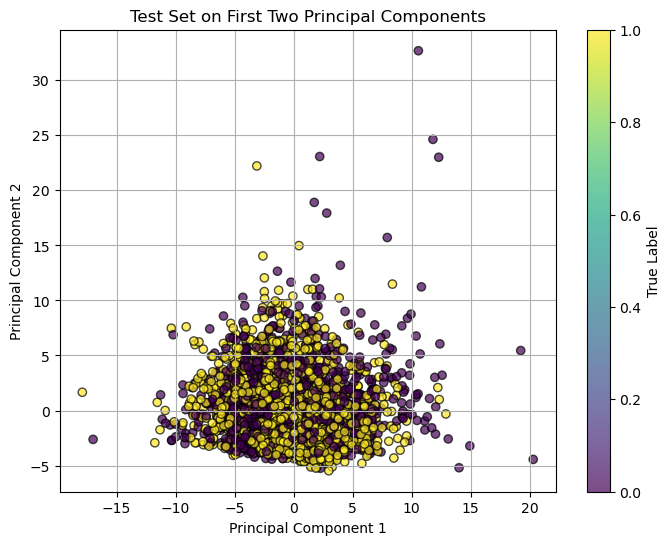

In [32]:
y_clean_HCC1806 = [element.strip('""').split("_")[1] for element in y_test_HCC1806_clustering]
color_HCC1806 = [0 if element == "Normoxia" else 1 for element in y_clean_HCC1806]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_test_HCC1806_clustering[:, 0], X_test_HCC1806_clustering[:, 1],
    c=color_HCC1806, cmap='viridis', edgecolor='k', alpha=0.7
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Test Set on First Two Principal Components')
plt.colorbar(scatter, label='True Label')
plt.grid(True)
plt.show()

In conclusion of the undupervised learning of the DropSeq HCC1806 database, we could not find satisfying enough results. The first indicator was the low explained variance by the first 50 principal components but that by itself was not enough to conclude that the biological differences are not as clear. Performing the clustering however we see that the model is having quite a bit of trouble and not matching very well with the true labels. 

## SmartSeq

### MCF7

#### PCA

We begin by doing principal component analysis. Although some feature selection has already been performed, we further decrease the dimension of our data. It will help reduce technical noise and emphasize the structured biological signal. It will also help with overfitting our models down the line. We first split our data into a test and train set to evaluate our prediction capacity. 

In [33]:
#Log transform
X_train_SSMCF7_log = np.log1p(X_train_SSMCF7)
X_test_SSMCF7_log = np.log1p(X_test_SSMCF7)

Now we do the actual PCA. We will see the result by plotting our samples (i.e cells) on the PC1 vs PC2 scale and mark the Normal and Hypoxic cells with different colors. What we actually see is that the two different types of cells are quite clearly separated along PC1. This suggest that the most dominant source of variance (i.e PC1) is very associated with the difference between hypoxic cells. This suggest that we are moving in the right directian and there is actual systematic and biological expression difference between the two types of cells we want to classify. We also plot the PCs based on their variance ratio which tells us how much each one explains of the total 

Explained variance by each PC: [0.18872314 0.05613299 0.03815598 0.02410154 0.01739784 0.01461397
 0.01336941 0.01188994 0.01078722 0.01040727 0.00983514 0.0093671
 0.008932   0.00814806 0.00765812 0.00755688 0.00714646 0.00683272
 0.00665075 0.00652416 0.00641102 0.00631321 0.00608306 0.00598416
 0.00587756 0.00576206 0.00567935 0.00550912 0.005487   0.00536418
 0.00522236 0.00511026 0.00502926 0.00495431 0.00487275 0.00481651
 0.00474523 0.00473022 0.00465226 0.00459717 0.00451852 0.004466
 0.0043909  0.00431527 0.00426839 0.004227   0.00413949 0.00406512
 0.00398515 0.00395351]
Explained variance: 0.6137610887684997


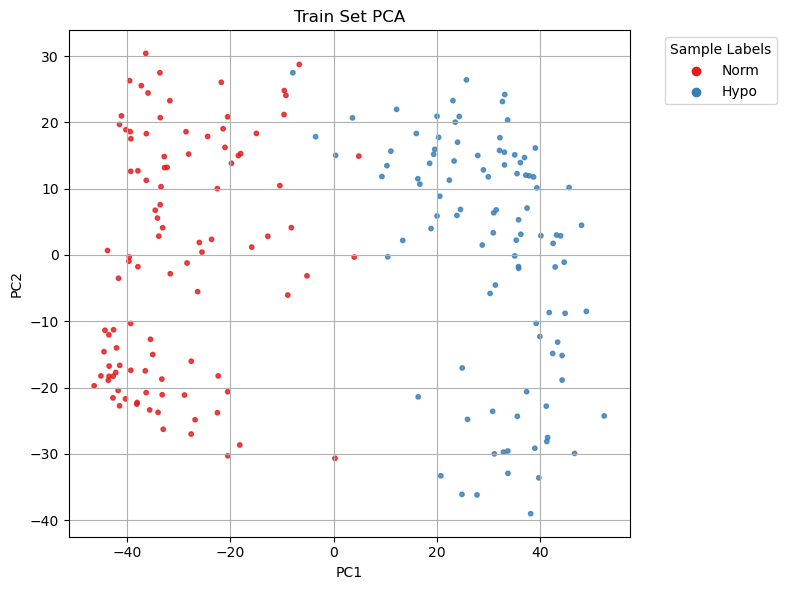

In [34]:
# PCA
pca = PCA(n_components=50)  # You can choose the number of PCs
X_train_pca_SSMCF7 = pca.fit_transform(X_train_SSMCF7_log)
X_test_pca_SSMCF7 = pca.transform(X_test_SSMCF7_log)

todata= pd.DataFrame(X_train_pca_SSMCF7)
todata.to_csv("../data/processed/X_train_pca_SSMCF7.csv", index=True)

# Explained variance
explained_var = pca.explained_variance_ratio_
explained_30 = explained_var.sum()
print("Explained variance by each PC:", explained_var)
print("Explained variance:", explained_30)

# Here we plot our data on the first two principal components
label_to_color = {
    'Norm': '#e41a1c',  # Bright red
    'Hypo': '#377eb8',  # Bold blue
}
colors = Xtrain_labels_SSMCF7.map(label_to_color)

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca_SSMCF7[:, 0], X_train_pca_SSMCF7[:, 1], c=colors, s=10, alpha=0.8)

for label, color in label_to_color.items():
    plt.scatter([], [], c=color, label=label)
plt.legend(title="Sample Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Train Set PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Clustering

Now that we have perfomed the PCA we can continue with the unsupervised learning with K-means clustering.

In [35]:
# Choose number of clusters (k)
k = 2  

# Train KMeans on PCA-transformed training data
kmeans = KMeans(n_clusters=k, random_state=0)
train_clusters = kmeans.fit_predict(X_train_pca_SSMCF7)

X_train_with_clusters = X_train_SSMCF7.copy()
X_train_with_clusters['kmeans_cluster'] = train_clusters

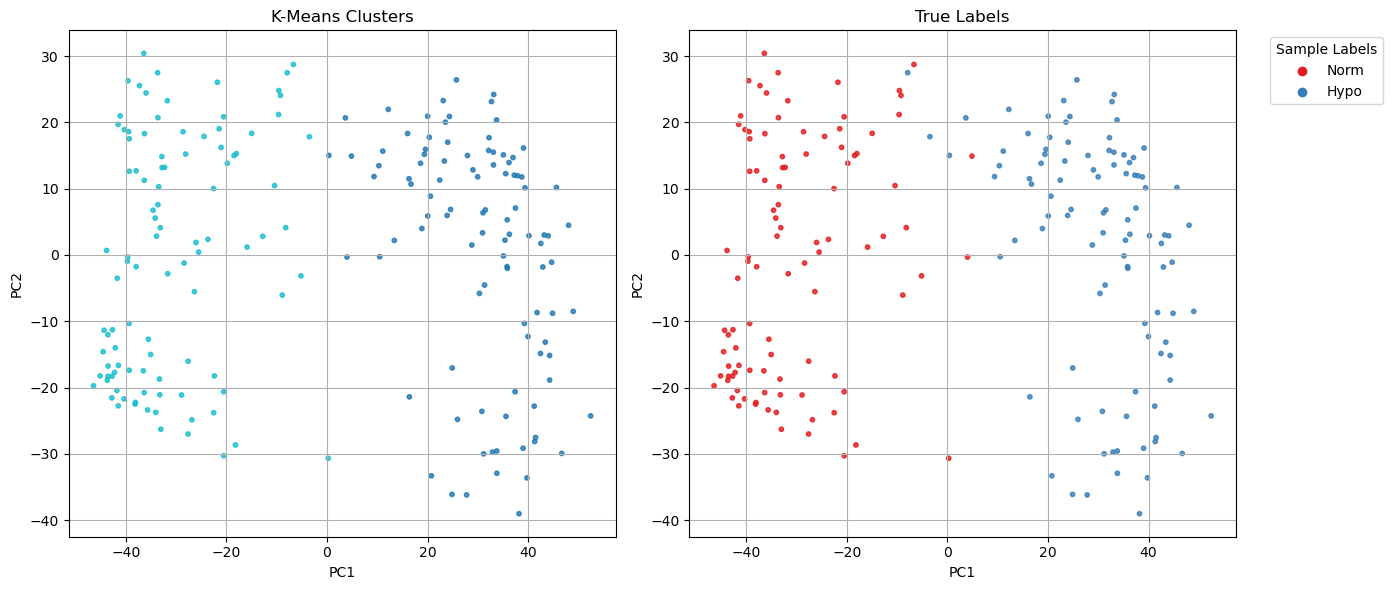

In [36]:
# Plot our data on the firt two principal components both colored by KMeans cluster and true label to visualy see the performance of the clustering 

label_to_color = {
    'Norm': '#e41a1c',  # red
    'Hypo': '#377eb8',  # blue
}
label_colors = Xtrain_labels_SSMCF7.map(label_to_color)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_train_pca_SSMCF7[:, 0],
    X_train_pca_SSMCF7[:, 1],
    c=train_clusters,
    cmap='tab10',
    s=10,
    alpha=0.8
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

scatter2 = axes[1].scatter(
    X_train_pca_SSMCF7[:, 0],
    X_train_pca_SSMCF7[:, 1],
    c=label_colors,
    s=10,
    alpha=0.8
)
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="Sample Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].set_title("True Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [37]:
# Compute Adjusted Rand Index (ARI) to numerically evaluate clustering performance
ari = adjusted_rand_score(Xtrain_labels_SSMCF7, train_clusters)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

Adjusted Rand Index (ARI): 0.921


For our results above we see that the ARI index is very high at 0.941 and on the visualization we see great similarities between our clusters and the true labels with just a few points that are incorrectly classified. Since we have not used the labels in the training this result is not to be underappreciated as it shows that there are clear biological differences between the hypoxic and normoxic cells that our clustering model has managed to identify with the help of our PCA. We now move to check the result on a separate set (the test set) that has not been used in neither the PCA nor the K-means clustering model to further check the accuracy and generalizability of our model. We see that the ARI index is 1, meaning we have achieved perfect prediction which can be seen on the plots as well. At first it might seem strange that our performance on the test set is better than on the training set, but that can be explained by outliers that could have made their way into our train set and a bit of 'luck' in the splitting of the data so that no such outliers were present in our test.

Adjusted Rand Index (ARI): 1.000


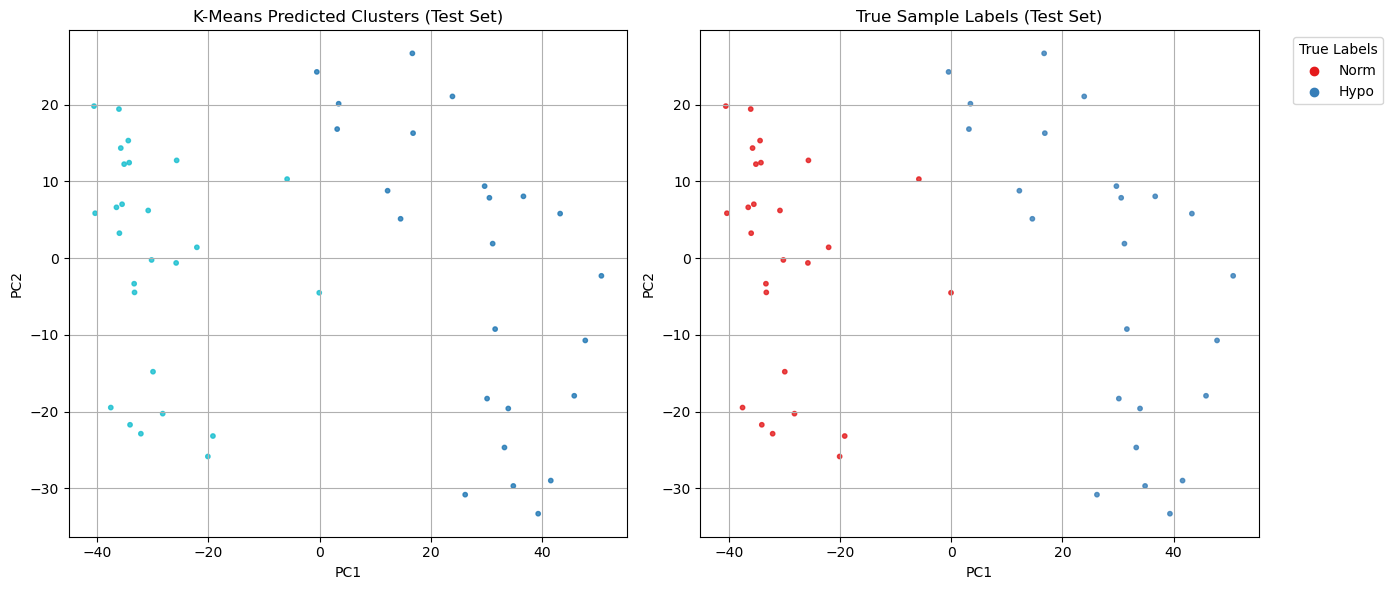

In [38]:
test_clusters = kmeans.predict(X_test_pca_SSMCF7)

ari = adjusted_rand_score(Xtest_labels_SSMCF7, test_clusters)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

# Map actual labels to colors
label_to_color = {
    'Norm': '#e41a1c',  # Red
    'Hypo': '#377eb8',  # Blue
}
true_colors = Xtest_labels_SSMCF7.map(label_to_color)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted clusters
axes[0].scatter(
    X_test_pca_SSMCF7[:, 0],
    X_test_pca_SSMCF7[:, 1],
    c=test_clusters,
    cmap='tab10',
    s=10,
    alpha=0.8
)
axes[0].set_title("K-Means Predicted Clusters (Test Set)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# Plot 2: True labels
axes[1].scatter(
    X_test_pca_SSMCF7[:, 0],
    X_test_pca_SSMCF7[:, 1],
    c=true_colors,
    s=10,
    alpha=0.8
)
# Add legend
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="True Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].set_title("True Sample Labels (Test Set)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### HCC1806

#### PCA

We begin by doing principal component analysis. Although some feature selection has already been performed, we further decrease the dimension of our data. It will help reduce technical noise and emphasize the structured biological signal. It will also help with overfitting our models down the line. 

Now we do the actual PCA. We will see the result by plotting our samples (i.e. cells) on the PC1 vs PC2 scale and by marking the Normal and Hypoxic cells with different colors. In the case of the SmartSeq HCC1806 database we see that the cells are not divided as clearly as in the previous case. Not only that but even though the main variance between the cells by definition along the first principal component, we see that the clusters of hypoxic vs normoxic cells seem to be separated along the PC2 axis. This is a very interesting result that could suggest a few different things. One could be that simply due to outliers in our data, they have thrown off our PCA and thus the main principal component is not the one that separates the two different types of cells (as we would have assumed as it would make sense the main source of variance to be related to the two different classifiers). This scenario is quite plausible as we can see that the big majority of samples are on the left hand side but just a few are very far on the right. So the variance along PC1 could have been precisely caused by these few cells. Another reason might be that other differences between the cells are also prominent which would suggest that the cells could have another separating factor or factors that we are not aware of. Plotting the data on our second and third principal components we see that a clear border is still not present but the main direction of variance (now PC2) aligns with the direction that roughly separates the two classes of cells. Either way, the cut is less clear than in the MCF7 case which could suggest that in this dataset of cells the biological difference between the two classes is not as prominent and thus not picked out by the PCA. We will continue with doing the clustering on the first 30 PCs and a second time on the same PCs but excluding PC1. In both cases the data is normalized, standardized and log-scaled for maximum success of the PCA.


Explained variance by each PC: [0.30952595 0.18087895 0.11647017 0.0898295  0.04267731 0.03809574
 0.02360878 0.01877666 0.01661739 0.01401188 0.0118263  0.01110767
 0.00862998 0.00768581 0.00689608 0.0060128  0.00541944 0.00513576
 0.00445211 0.00412326 0.00374888 0.00352527 0.00346494 0.00316712
 0.0028546  0.00259971 0.00241251 0.00231038 0.00216966 0.00209557]
Explained variance: 0.9501301825159376


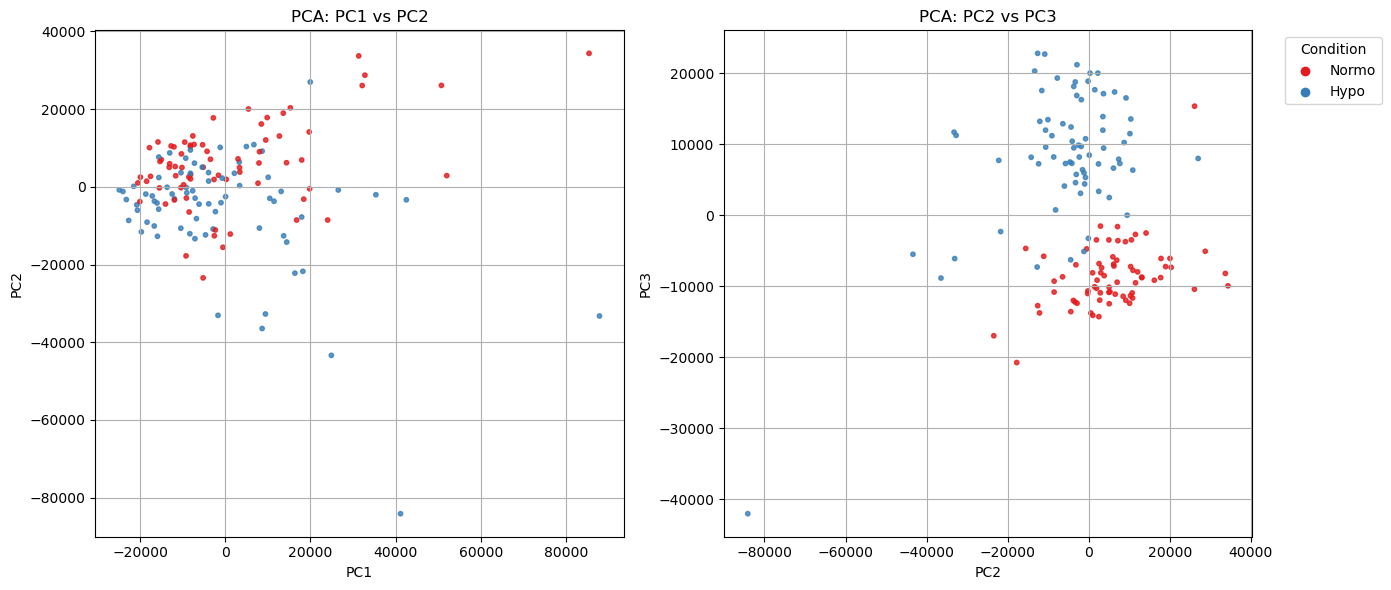

In [39]:
# PCA
pca = PCA(n_components=30)  # You can choose the number of PCs
X_train_pca_SSHCC1806 = pca.fit_transform(X_train_SSHCC1806)
X_test_pca_SSHCC1806 = pca.transform(X_test_SSHCC1806)

todata= pd.DataFrame(X_train_pca_SSHCC1806)
todata.to_csv("../data/processed/X_train_pca_SSHCC1806.csv", index=True)

# Explained variance
explained_var = pca.explained_variance_ratio_
explained_30 = explained_var.sum()
print("Explained variance by each PC:", explained_var)
print("Explained variance:", explained_30)

# Plot on PC1 vs PC2 and PC2 vs PC3

label_to_color = {
    'Normo': '#e41a1c',  # red
    'Hypo': '#377eb8',   # blue
}

# Map labels to colors
true_colors = Xtrain_labels_SSHCC1806.map(label_to_color).fillna('#999999')  # fallback gray for unmapped

# Start plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Plot 1: PC1 vs PC2 ----
axes[0].scatter(
    X_train_pca_SSHCC1806[:, 0],  # PC1
    X_train_pca_SSHCC1806[:, 1],  # PC2
    c=true_colors,
    s=10,
    alpha=0.8
)
axes[0].set_title("PCA: PC1 vs PC2")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# ---- Plot 2: PC2 vs PC3 ----
axes[1].scatter(
    X_train_pca_SSHCC1806[:, 1],  # PC2
    X_train_pca_SSHCC1806[:, 2],  # PC3
    c=true_colors,
    s=10,
    alpha=0.8
)
axes[1].set_title("PCA: PC2 vs PC3")
axes[1].set_xlabel("PC2")
axes[1].set_ylabel("PC3")
axes[1].grid(True)

# Add a shared legend
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

First we start by the K-means clustering on PC2 to PC30. We plot the data on the first two PCs but that is of not too great importance as we seek to compare the true labels vs the cluster labels. What we see is that the model is relatively successful but again, due to the unclear separation of the data, does poorer compared to the SmartSeq MCF7 case. Our Adjusted Rand Index is 0.64 where 1 is perfect and 0 is as good as random. The score is not terrible but a stronger model would be required for further improvement.

#### Clustering

In [40]:
# Choose number of clusters (k)
k = 2  

X_train_sub_SSHC1806 = X_train_pca_SSHCC1806[:, 1:30]
X_test_sub_SSHC1806 = X_test_pca_SSHCC1806[:, 1:30]

# Train KMeans on PCA-transformed training data
kmeans = KMeans(n_clusters=k, random_state=0)
train_clusters = kmeans.fit_predict(X_train_sub_SSHC1806)


X_train_with_clusters = X_train_SSHCC1806.copy()
X_train_with_clusters['kmeans_cluster'] = train_clusters

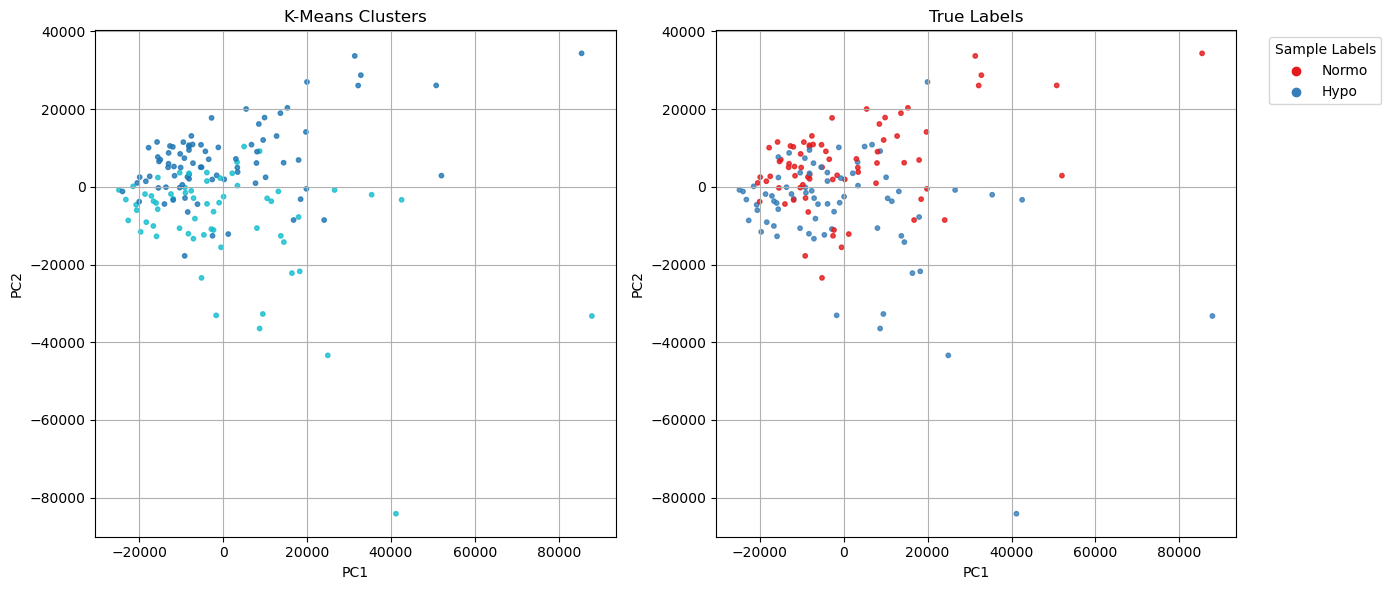

In [41]:
# Plot our data on the firt two principal components both colored by KMeans cluster and true label to visualy see the performance of the clustering 

label_to_color = {
    'Normo': '#e41a1c',  # red
    'Hypo': '#377eb8',  # blue
}
label_colors = Xtrain_labels_SSHCC1806.map(label_to_color)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_train_pca_SSHCC1806[:, 0],
    X_train_pca_SSHCC1806[:, 1],
    c=train_clusters,
    cmap='tab10',
    s=10,
    alpha=0.8
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

scatter2 = axes[1].scatter(
    X_train_pca_SSHCC1806[:, 0],
    X_train_pca_SSHCC1806[:, 1],
    c=label_colors,
    s=10,
    alpha=0.8
)
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="Sample Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].set_title("True Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [42]:
ari = adjusted_rand_score(Xtrain_labels_SSHCC1806, train_clusters)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

Adjusted Rand Index (ARI): 0.605


Doing the model on all of the first 30 principal components we see that the results are much worse. The first principal component dominates the clustering and all of the values are labeled the same way. This clearly presents the issue that we tried to fix above of having a component that accounts for higher variance that is not aligned with our classifiers. As we can see, the model performs worse when we take into consideration the first PC.


In [43]:
# Choose number of clusters (k)
k = 2  

# Train KMeans on PCA-transformed training data
kmeans2 = KMeans(n_clusters=k, random_state=0)
train_clusters2 = kmeans2.fit_predict(X_train_pca_SSHCC1806[:, :30])


X_train_with_clusters = X_train_SSHCC1806.copy()
X_train_with_clusters['kmeans_cluster'] = train_clusters2

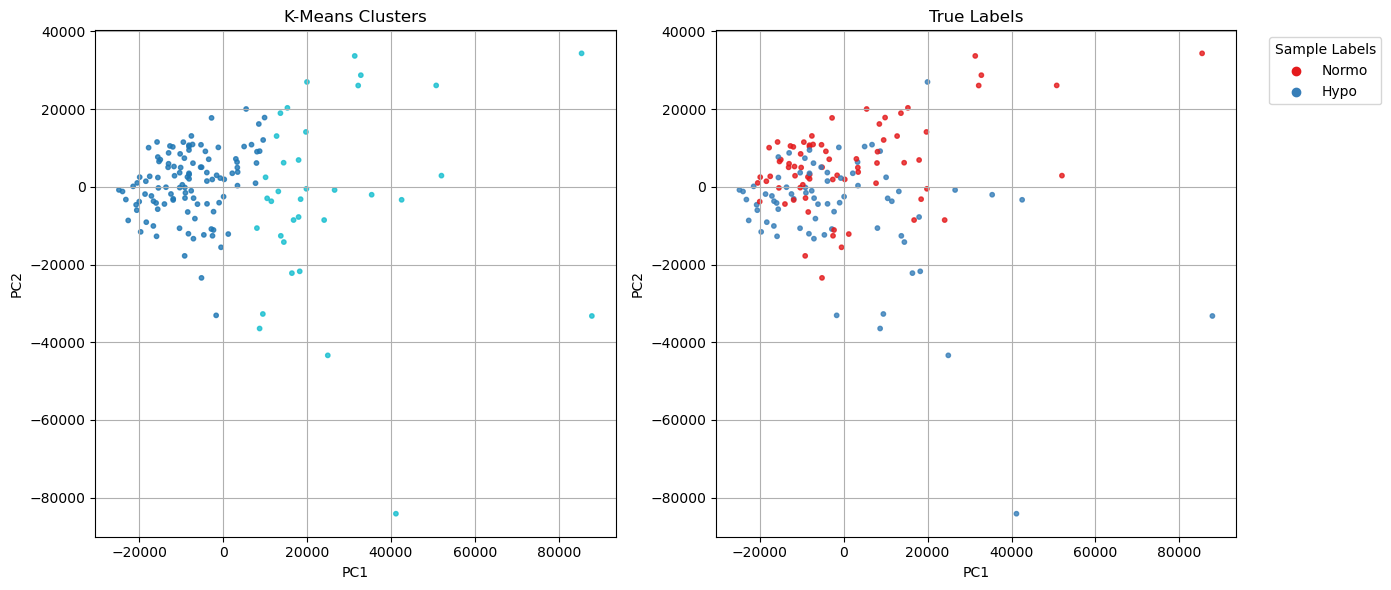

In [44]:
# Plot our data on the firt two principal components both colored by KMeans cluster and true label to visualy see the performance of the clustering 

label_to_color = {
    'Normo': '#e41a1c',  # red
    'Hypo': '#377eb8',  # blue
}
label_colors = Xtrain_labels_SSHCC1806.map(label_to_color)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(
    X_train_pca_SSHCC1806[:, 0],
    X_train_pca_SSHCC1806[:, 1],
    c=train_clusters2,
    cmap='tab10',
    s=10,
    alpha=0.8
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

scatter2 = axes[1].scatter(
    X_train_pca_SSHCC1806[:, 0],
    X_train_pca_SSHCC1806[:, 1],
    c=label_colors,
    s=10,
    alpha=0.8
)
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="Sample Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].set_title("True Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [45]:
# Compute Adjusted Rand Index (ARI) to numerically evaluate clustering performance


ari = adjusted_rand_score(Xtrain_labels_SSHCC1806, train_clusters2)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

Adjusted Rand Index (ARI): -0.004


Clearly, it is better to not use the first PC and this is why we perform the test on the training set with the clustering based on the PCs without the first one. We are getting a better score even than on the training set, but that could be due to a particularly lucky choice of training sample and not many samples in the training set. On the graph we can see that the clustering seems to separate the data quite closely as to how it is supposed to be separated and the ARI index confirms it.


(37,)
(37, 30)
(145, 30)


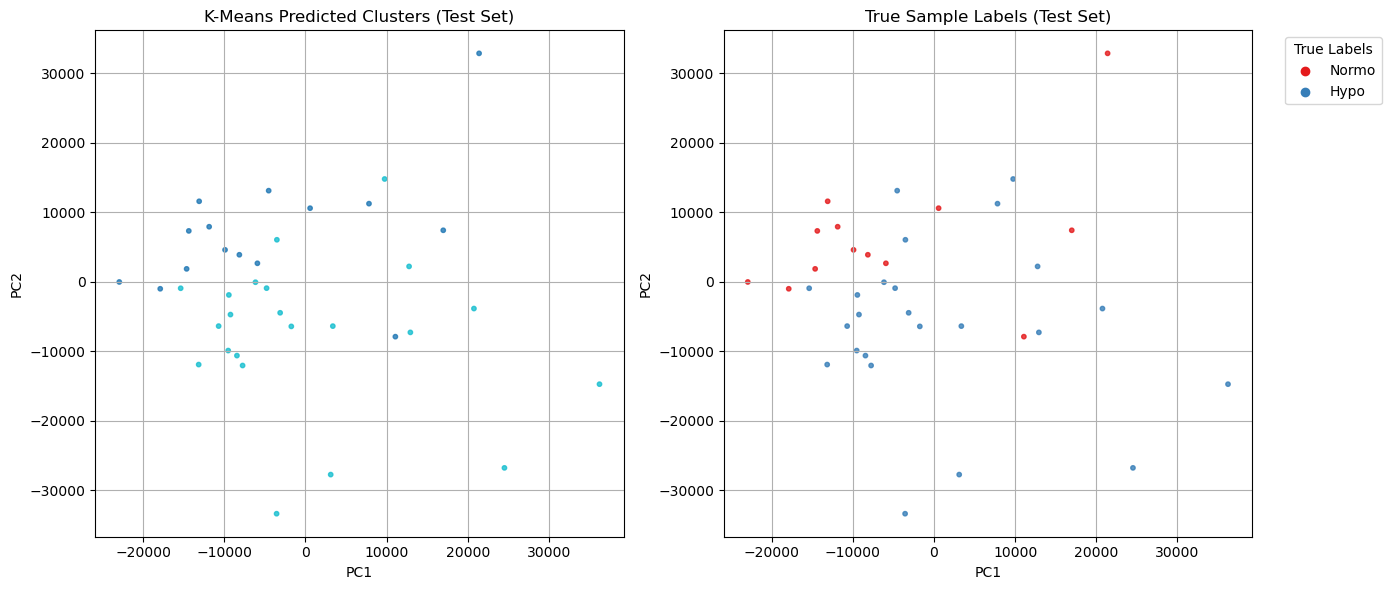

In [46]:
# Standardize using training scaler

test_clusters = kmeans.predict(X_test_sub_SSHC1806)

# Map actual labels to colors
label_to_color = {
    'Normo': '#e41a1c',  # Red
    'Hypo': '#377eb8',  # Blue
}

true_colors = Xtest_labels_SSHCC1806.map(label_to_color)
print(true_colors.shape)
print(X_test_pca_SSHCC1806.shape)
print(X_train_pca_SSHCC1806.shape)
# # Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Plot 1: Predicted clusters
axes[0].scatter(
     X_test_pca_SSHCC1806[:, 0],
     X_test_pca_SSHCC1806[:, 1],
     c=test_clusters,
     cmap='tab10',
     s=10,
     alpha=0.8
 )
axes[0].set_title("K-Means Predicted Clusters (Test Set)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True)

# # Plot 2: True labels
axes[1].scatter(
    X_test_pca_SSHCC1806[:, 0],
    X_test_pca_SSHCC1806[:, 1],
    c=true_colors,
    s=10,
    alpha=0.8
)
# # Add legend
for label, color in label_to_color.items():
    axes[1].scatter([], [], c=color, label=label)
axes[1].legend(title="True Labels", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[1].set_title("True Sample Labels (Test Set)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True)

plt.tight_layout()
plt.show()



In [47]:
ari = adjusted_rand_score(Xtest_labels_SSHCC1806, test_clusters)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")

Adjusted Rand Index (ARI): 0.790
